# Packages

In [206]:
!python --version

Python 3.12.12


In [207]:
!pip install scikit-learn scikit-learn-extra pyclustering

In [259]:
from pyclustering.cluster.kmedoids import kmedoids
from pyclustering.utils.metric import distance_metric, type_metric
from scipy.optimize import linear_sum_assignment
from sklearn import datasets, metrics
from sklearn.cluster import AgglomerativeClustering, DBSCAN, KMeans, OPTICS
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.decomposition import PCA
from sklearn.metrics import pairwise_distances
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
# from sklearn_extra.cluster import KMedoids # not fully supported in py V3.12.x

import itertools
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Datasets

In [209]:
def load_dataset(name: str):
    """
    Load a UCI dataset by name and ensure target labels are integer-encoded (0, 1, 2, ...).

    Parameters
    ----------
    name : str
        Name of the dataset. Supported values: 'iris', 'wine'.

    Returns
    -------
    X : np.ndarray
        Feature matrix of shape (n_samples, n_features).
    y : np.ndarray
        Integer-encoded labels starting from 0.
    feature_names : list of str
        Names of the features.
    target_names : list of str
        Original target class names.

    Raises
    ------
    ValueError
        If an unsupported dataset name is provided.
    """
    name = name.lower().strip()

    if name == 'iris':
        data = datasets.load_iris()
    elif name == 'wine':
        data = datasets.load_wine()
    else:
        raise ValueError(f"Unsupported dataset name: {name}. Use 'iris' or 'wine'.")

    X = data.data
    y = data.target

    # Ensure labels are 0-indexed integers (sklearn already provides them this way, but enforce for safety)
    unique_labels, y_mapped = np.unique(y, return_inverse=True)
    y = y_mapped  # Now y contains 0,1,2,...

    feature_names = list(data.feature_names)
    target_names = list(data.target_names)

    print(f"Loaded '{name}' dataset: {X.shape[0]} samples, {X.shape[1]} features, {len(np.unique(y))} classes.")
    return X, y, feature_names, target_names

# Pre-processing

## Scaling Function

In [210]:
def preprocess_data(X):
    """
    Standardize features to zero mean and unit variance.

    Parameters
    ----------
    X : np.ndarray
        Raw feature matrix of shape (n_samples, n_features).

    Returns
    -------
    X_scaled : np.ndarray
        Scaled feature matrix with mean ≈ 0 and std ≈ 1.
    scaler : StandardScaler
        Fitted scaler instance for potential inverse transformation.
    """
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # Display summary statistics for verification
    print("Preprocessing complete:")
    print(f"  - Mean of each feature after scaling (approx): {np.round(X_scaled.mean(axis=0), 4)}")
    print(f"  - Std of each feature after scaling (approx): {np.round(X_scaled.std(axis=0), 4)}")

    return X_scaled, scaler

## Plot Clusters




In [211]:
def plot_clusters(X, y_pred, title="Clusters"):
    pca = PCA(n_components=2)
    X_2d = pca.fit_transform(X)
    plt.figure(figsize=(6,5))
    plt.scatter(X_2d[:,0], X_2d[:,1], c=y_pred, cmap='tab10', s=50)
    plt.title(title)
    plt.show()

# Evaluation Metrics Utility

In [212]:
def compute_sse_ssb(X, labels):
    """
    Compute cohesion (SSE) and separation (SSB) for clustering results.

    Parameters
    ----------
    X : np.ndarray
        Feature matrix of shape (n_samples, n_features).
    labels : np.ndarray
        Cluster labels (integers 0, 1, ..., k-1).

    Returns
    -------
    sse : float
        Sum of Squared Errors within clusters (cohesion).
    ssb : float
        Sum of Squares Between clusters (separation).
    """
    X = np.asarray(X)
    labels = np.asarray(labels)

    # Overall mean (centroid of entire dataset)
    global_mean = np.mean(X, axis=0)

    # Unique clusters and their centroids
    unique_labels = np.unique(labels)
    sse, ssb = 0.0, 0.0

    for lbl in unique_labels:
        cluster_points = X[labels == lbl]
        if len(cluster_points) == 0:
            continue
        cluster_mean = np.mean(cluster_points, axis=0)
        # Cohesion: within-cluster variance
        sse += np.sum((cluster_points - cluster_mean) ** 2)
        # Separation: between-cluster variance weighted by cluster size
        ssb += len(cluster_points) * np.sum((cluster_mean - global_mean) ** 2)

    return sse, ssb

In [213]:
def cluster_accuracy(y_true, y_pred):
    """
    Compute clustering accuracy using optimal label mapping (Hungarian algorithm).

    Parameters
    ----------
    y_true : np.ndarray
        True class labels (integers).
    y_pred : np.ndarray
        Predicted cluster labels (integers).

    Returns
    -------
    accuracy : float
        Best possible accuracy after optimal cluster-to-label assignment.
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    D = metrics.cluster.contingency_matrix(y_true, y_pred)
    row_ind, col_ind = linear_sum_assignment(-D)
    accuracy = D[row_ind, col_ind].sum() / np.sum(D)
    return accuracy

In [214]:
def evaluate_clustering(X, y_true, y_pred):
    """
    Compute all clustering evaluation metrics.

    Parameters
    ----------
    X : np.ndarray
        Feature matrix.
    y_true : np.ndarray
        True class labels.
    y_pred : np.ndarray
        Predicted cluster labels.

    Returns
    -------
    results : dict
        Dictionary containing all evaluation metrics.
    """
    # Handle edge cases (e.g., all points in one cluster)
    n_clusters = len(np.unique(y_pred))
    if n_clusters <= 1:
        return {
            "Rand": np.nan,
            "Adj Rand": np.nan,
            "MI": np.nan,
            "Adj MI": np.nan,
            "Norm MI": np.nan,
            "Silhouette": np.nan,
            "Calinski": np.nan,
            "Davies": np.nan,
            "SSE": np.nan,
            "SSB": np.nan,
            "Accuracy": np.nan
        }

    # External metrics
    rand = metrics.rand_score(y_true, y_pred)
    adj_rand = metrics.adjusted_rand_score(y_true, y_pred)
    mi = metrics.mutual_info_score(y_true, y_pred)
    adj_mi = metrics.adjusted_mutual_info_score(y_true, y_pred)
    norm_mi = metrics.normalized_mutual_info_score(y_true, y_pred)

    # Internal metrics
    silhouette = metrics.silhouette_score(X, y_pred)
    calinski = metrics.calinski_harabasz_score(X, y_pred)
    davies = metrics.davies_bouldin_score(X, y_pred)

    # Cohesion / separation
    sse, ssb = compute_sse_ssb(X, y_pred)

    # Accuracy (derived)
    acc = cluster_accuracy(y_true, y_pred)

    return {
        "Rand": rand,
        "Adj Rand": adj_rand,
        "MI": mi,
        "Adj MI": adj_mi,
        "Norm MI": norm_mi,
        "Silhouette": silhouette,
        "Calinski": calinski,
        "Davies": davies,
        "SSE": sse,
        "SSB": ssb,
        "Accuracy": acc
    }

# Partition Based Clustering

## K-Means

### K-Means++

In [215]:
def run_kmeans(X, y_true, k=3, n_init=10, random_state=0):
    """
    Perform K-Means clustering and evaluate performance.

    Parameters
    ----------
    X : np.ndarray
        Scaled feature matrix of shape (n_samples, n_features).
    y_true : np.ndarray
        True class labels (for external evaluation).
    k : int, default=3
        Number of clusters.
    n_init : int, default=10
        Number of random initializations.
    random_state : int, default=0
        Random seed for reproducibility.

    Returns
    -------
    results : dict
        Dictionary containing evaluation metrics and K-Means parameters.
    y_pred : np.ndarray
        Predicted cluster labels.
    centers : np.ndarray
        Cluster centroids.
    """
    # Initialize and fit K-Means
    kmeans = KMeans(
        n_clusters=k,
        init='k-means++',      # uses the K-means++ initialization method
        n_init=n_init,
        max_iter=300,
        random_state=random_state
    )

    y_pred = kmeans.fit_predict(X)
    centers = kmeans.cluster_centers_

    # Evaluate clustering
    eval_results = evaluate_clustering(X, y_true, y_pred)

    # Add algorithm info
    eval_results["Algorithm"] = f"KMeans (k={k})"

    return eval_results, y_pred, centers


### Bisecting K-Means

In [216]:
def run_bisecting_kmeans(X, y_true, k=3, n_init=10, random_state=0, max_iter=10):
    """
    Perform Bisecting K-Means clustering and evaluate performance.

    Parameters
    ----------
    X : np.ndarray
        Scaled feature matrix (n_samples, n_features).
    y_true : np.ndarray
        True class labels (for evaluation).
    k : int, default=3
        Desired number of final clusters.
    n_init : int, default=10
        Number of initializations for K-Means at each split.
    random_state : int, default=0
        Random seed for reproducibility.
    max_iter : int, default=10
        Maximum number of bisection iterations per cluster.

    Returns
    -------
    results : dict
        Evaluation metrics for Bisecting K-Means.
    y_pred : np.ndarray
        Predicted cluster labels.
    cluster_centers : list
        List of cluster centroids.
    """

    np.random.seed(random_state)
    n_samples = X.shape[0]

    # Start with one cluster containing all points
    clusters = {0: np.arange(n_samples)}

    # Keep splitting until desired number of clusters reached
    while len(clusters) < k:
        # Step 1: Select the cluster with largest SSE
        sse_per_cluster = {}
        for cid, indices in clusters.items():
            subset = X[indices]
            center = np.mean(subset, axis=0)
            sse = np.sum((subset - center) ** 2)
            sse_per_cluster[cid] = sse

        # Select cluster with largest SSE
        cluster_to_split = max(sse_per_cluster, key=sse_per_cluster.get)
        indices_to_split = clusters[cluster_to_split]
        X_subset = X[indices_to_split]

        # Step 2: Bisect (apply K-Means with k=2)
        best_labels = None
        best_inertia = np.inf

        for i in range(max_iter):
            kmeans_2 = KMeans(
                n_clusters=2,
                n_init=n_init,
                random_state=random_state + i
            ).fit(X_subset)

            if kmeans_2.inertia_ < best_inertia:
                best_labels = kmeans_2.labels_
                best_inertia = kmeans_2.inertia_

        # Step 3: Replace old cluster with new two clusters
        new_cluster_id = max(clusters.keys()) + 1
        clusters[cluster_to_split] = indices_to_split[best_labels == 0]
        clusters[new_cluster_id] = indices_to_split[best_labels == 1]

    # Construct final label array
    y_pred = np.zeros(n_samples, dtype=int)
    for cid, indices in clusters.items():
        y_pred[indices] = cid

    # Compute cluster centers
    cluster_centers = [np.mean(X[indices], axis=0) for indices in clusters.values()]

    # Evaluate
    eval_results = evaluate_clustering(X, y_true, y_pred)
    eval_results["Algorithm"] = f"Bisecting KMeans (k={k})"

    return eval_results, y_pred, cluster_centers


## K-Medoids

In [217]:
def run_kmedoids(X, y_true, k=3, metric='euclidean', random_state=0):
    """
    Perform K-Medoids (PAM) clustering using pyclustering implementation.

    Parameters
    ----------
    X : np.ndarray
        Scaled feature matrix (n_samples, n_features).
    y_true : np.ndarray
        True class labels (for external evaluation).
    k : int, default=3
        Number of clusters.
    metric : str, default='euclidean'
        Distance metric ('euclidean', 'manhattan', etc.)
    random_state : int, default=0
        Random seed.

    Returns
    -------
    results : dict
        Evaluation metrics.
    y_pred : np.ndarray
        Predicted cluster labels.
    medoids : list
        Indices of medoid samples.
    """
    np.random.seed(random_state)
    n_samples = X.shape[0]

    # Randomly choose initial medoids
    initial_medoids = np.random.choice(n_samples, k, replace=False).tolist()

    # Configure distance metric
    if metric == 'euclidean':
        metric_func = distance_metric(type_metric.EUCLIDEAN)
    elif metric == 'manhattan':
        metric_func = distance_metric(type_metric.MANHATTAN)
    else:
        raise ValueError("Unsupported metric. Use 'euclidean' or 'manhattan'.")

    # Run PAM (K-Medoids)
    kmedoids_instance = kmedoids(X, initial_medoids, metric=metric_func)
    kmedoids_instance.process()

    clusters = kmedoids_instance.get_clusters()
    medoids = kmedoids_instance.get_medoids()

    # Convert cluster list to label array
    y_pred = np.zeros(n_samples, dtype=int)
    for cluster_idx, cluster_points in enumerate(clusters):
        y_pred[cluster_points] = cluster_idx

    # Evaluate
    eval_results = evaluate_clustering(X, y_true, y_pred)
    eval_results["Algorithm"] = f"KMedoids (k={k})"

    return eval_results, y_pred, medoids

# Hierarchical Clustering

## Agglomerative (With Dendrogram)

In [218]:
def run_hierarchical(X, y_true, k=3, linkage_method='ward', plot_dendrogram=True):
    """
    Perform Agglomerative Hierarchical Clustering and evaluate performance.
    Optionally plot the dendrogram.

    Parameters
    ----------
    X : np.ndarray
        Scaled feature matrix (n_samples, n_features).
    y_true : np.ndarray
        True class labels (for evaluation).
    k : int, default=3
        Desired number of clusters.
    linkage_method : str, default='ward'
        Linkage criterion ('ward', 'complete', 'average', 'single').
    plot_dendrogram : bool, default=True
        Whether to display the dendrogram plot.

    Returns
    -------
    results : dict
        Evaluation metrics and algorithm info.
    y_pred : np.ndarray
        Predicted cluster labels.
    """
    # Perform Agglomerative Clustering
    hc = AgglomerativeClustering(
        n_clusters=k,
        metric='euclidean',
        linkage=linkage_method
    )
    y_pred = hc.fit_predict(X)

    # Evaluate clustering
    eval_results = evaluate_clustering(X, y_true, y_pred)
    eval_results["Algorithm"] = f"Hierarchical ({linkage_method}, k={k})"

    # Optionally plot dendrogram
    if plot_dendrogram:
        plt.figure(figsize=(10, 5))
        Z = linkage(X, method=linkage_method)
        dendrogram(Z, truncate_mode='level', p=5)
        plt.title(f"Dendrogram ({linkage_method} linkage)")
        plt.xlabel("Samples")
        plt.ylabel("Distance")
        plt.show()

    return eval_results, y_pred

## Divisive (Generic)

In [219]:
def run_divisive_hierarchical(X, y_true, k=3, n_init=10, random_state=0):
    """
    Perform divisive hierarchical clustering using recursive bisecting K-Means.

    Parameters
    ----------
    X : np.ndarray
        Scaled feature matrix (n_samples, n_features)
    y_true : np.ndarray
        True class labels (for evaluation)
    k : int
        Desired number of clusters
    n_init : int
        Number of initializations for K-Means at each split
    random_state : int
        Random seed

    Returns
    -------
    eval_results : dict
        Clustering evaluation metrics
    y_pred : np.ndarray
        Predicted cluster labels
    """
    np.random.seed(random_state)
    n_samples = X.shape[0]

    # Each element is a tuple: (indices of cluster points)
    clusters = [np.arange(n_samples)]

    while len(clusters) < k:
        # Select cluster with largest SSE to split
        sse_per_cluster = []
        for idx, indices in enumerate(clusters):
            subset = X[indices]
            center = np.mean(subset, axis=0)
            sse = np.sum((subset - center) ** 2)
            sse_per_cluster.append(sse)
        cluster_to_split_idx = np.argmax(sse_per_cluster)
        indices_to_split = clusters.pop(cluster_to_split_idx)
        X_subset = X[indices_to_split]

        # Split into 2 using K-Means
        kmeans_2 = KMeans(n_clusters=2, n_init=n_init, random_state=random_state)
        labels_split = kmeans_2.fit_predict(X_subset)

        # Append the two new clusters
        clusters.append(indices_to_split[labels_split == 0])
        clusters.append(indices_to_split[labels_split == 1])

    # Build final label array
    y_pred = np.zeros(n_samples, dtype=int)
    for cid, indices in enumerate(clusters):
        y_pred[indices] = cid

    # Evaluate clustering
    eval_results = evaluate_clustering(X, y_true, y_pred)
    eval_results["Algorithm"] = f"Divisive Hierarchical (k={k})"

    return eval_results, y_pred

## Divisive (Exhaustive)

In [220]:
def exact_divisive(X, y_true, k=3):
    """
    Perform exact recursive divisive hierarchical clustering (exhaustive bipartition search).

    Parameters
    ----------
    X : np.ndarray
        Feature matrix (n_samples, n_features)
    y_true : np.ndarray
        True labels for evaluation
    k : int
        Desired number of clusters

    Returns
    -------
    eval_results : dict
        Evaluation metrics
    y_pred : np.ndarray
        Cluster labels
    """
    n_samples = X.shape[0]
    clusters = [np.arange(n_samples)]

    while len(clusters) < k:
        # Select cluster to split (largest SSE)
        sse_per_cluster = []
        for indices in clusters:
            subset = X[indices]
            sse = np.sum((subset - subset.mean(axis=0)) ** 2)
            sse_per_cluster.append(sse)
        cluster_to_split_idx = np.argmax(sse_per_cluster)
        indices_to_split = clusters.pop(cluster_to_split_idx)
        n = len(indices_to_split)

        if n > 20:
            # fallback to bisecting K-Means for large clusters
            from sklearn.cluster import KMeans
            kmeans_2 = KMeans(n_clusters=2, n_init=10, random_state=0)
            labels_split = kmeans_2.fit_predict(X[indices_to_split])
        else:
            # exact exhaustive search for bipartitions
            best_ssb = -np.inf
            best_split = None
            # generate all non-trivial bipartitions
            for r in range(1, n // 2 + 1):
                for combo in itertools.combinations(range(n), r):
                    mask = np.zeros(n, dtype=bool)
                    mask[list(combo)] = True
                    group1 = X[indices_to_split][mask]
                    group2 = X[indices_to_split][~mask]
                    # compute SSB
                    overall_mean = X[indices_to_split].mean(axis=0)
                    ssb = (len(group1) * np.sum((group1.mean(axis=0) - overall_mean) ** 2) +
                           len(group2) * np.sum((group2.mean(axis=0) - overall_mean) ** 2))
                    if ssb > best_ssb:
                        best_ssb = ssb
                        best_split = mask
            labels_split = best_split.astype(int)

        # Add new clusters
        clusters.append(indices_to_split[labels_split == 0])
        clusters.append(indices_to_split[labels_split == 1])

    # Construct final label array
    y_pred = np.zeros(n_samples, dtype=int)
    for cid, indices in enumerate(clusters):
        y_pred[indices] = cid

    # Evaluate
    eval_results = evaluate_clustering(X, y_true, y_pred)
    eval_results["Algorithm"] = f"Exact Divisive Hierarchical (k={k})"
    return eval_results, y_pred

# Density Based Clustering

In [221]:
def run_density_based(X, y_true, method='dbscan', eps=0.5, min_samples=5, xi=0.05, min_cluster_size=5):
    """
    Run density-based clustering (DBSCAN or OPTICS) and evaluate performance.

    Parameters
    ----------
    X : np.ndarray
        Scaled feature matrix
    y_true : np.ndarray
        True class labels
    method : str, default='dbscan'
        'dbscan' or 'optics'
    eps : float
        Neighborhood radius (DBSCAN)
    min_samples : int
        Minimum samples for core point (DBSCAN)
    xi : float
        Sensitivity parameter for OPTICS (optional)
    min_cluster_size : int
        Minimum cluster size for OPTICS

    Returns
    -------
    eval_results : dict
        Evaluation metrics
    y_pred : np.ndarray
        Cluster labels
    """

    if method.lower() == 'dbscan':
        clusterer = DBSCAN(eps=eps, min_samples=min_samples)
    elif method.lower() == 'optics':
        clusterer = OPTICS(xi=xi, min_samples=min_samples, min_cluster_size=min_cluster_size)
    else:
        raise ValueError("method must be 'dbscan' or 'optics'")

    y_pred = clusterer.fit_predict(X)

    # Optional: relabel noise (-1) as a separate cluster for evaluation
    y_pred_eval = np.copy(y_pred)
    if -1 in y_pred_eval:
        y_pred_eval[y_pred_eval == -1] = np.max(y_pred_eval) + 1

    eval_results = evaluate_clustering(X, y_true, y_pred_eval)
    eval_results["Algorithm"] = f"{method.upper()}"

    return eval_results, y_pred

# Usage

## Example

In [226]:
X_iris, y_iris, feat_iris, target_iris = load_dataset('iris')
print("Unique labels (Iris):", np.unique(y_iris))
print("First 5 samples:\n", X_iris[:5])

X_wine, y_wine, feat_wine, target_wine = load_dataset('wine')
print("Unique labels (Wine):", np.unique(y_wine))

Loaded 'iris' dataset: 150 samples, 4 features, 3 classes.
Unique labels (Iris): [0 1 2]
First 5 samples:
 [[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]]
Loaded 'wine' dataset: 178 samples, 13 features, 3 classes.
Unique labels (Wine): [0 1 2]


In [21]:
X_iris_scaled, scaler_iris = preprocess_data(X_iris)

X_wine_scaled, scaler_wine = preprocess_data(X_wine)

Preprocessing complete:
  - Mean of each feature after scaling (approx): [-0. -0. -0. -0.]
  - Std of each feature after scaling (approx): [1. 1. 1. 1.]
Preprocessing complete:
  - Mean of each feature after scaling (approx): [ 0.  0. -0. -0. -0. -0.  0. -0. -0. -0.  0.  0. -0.]
  - Std of each feature after scaling (approx): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [44]:
# Run K-Means
results_kmeans, y_pred_kmeans, centers_kmeans = run_kmeans(X_iris_scaled, y_iris, k=3, n_init=10)

# Display results neatly
pd.DataFrame([results_kmeans]).set_index("Algorithm")

,Rand,Adj Rand,MI,Adj MI,Norm MI,Silhouette,Calinski,Davies,SSE,SSB,Accuracy
Algorithm,,,,,,,,,,,
KMeans (k=3),0.832215,0.620135,0.724124,0.655223,0.659487,0.459948,241.904402,0.833595,139.820496,460.179504,0.833333


In [58]:
# Run K-Medoids
results_kmedoids, y_pred_kmedoids, medoids = run_kmedoids(X_iris_scaled, y_iris, k=3)

# Display results
pd.DataFrame([results_kmedoids]).set_index("Algorithm")

,Rand,Adj Rand,MI,Adj MI,Norm MI,Silhouette,Calinski,Davies,SSE,SSB,Accuracy
Algorithm,,,,,,,,,,,
KMedoids (k=3),0.856823,0.676454,0.767794,0.696651,0.70041,0.450791,238.547924,0.831681,141.324446,458.675554,0.866667


In [64]:
# Run Bisecting K-Means
results_bkm, y_pred_bkm, centers_bkm = run_bisecting_kmeans(X_iris_scaled, y_iris, k=3)

# Display results
pd.DataFrame([results_bkm]).set_index("Algorithm")

,Rand,Adj Rand,MI,Adj MI,Norm MI,Silhouette,Calinski,Davies,SSE,SSB,Accuracy
Algorithm,,,,,,,,,,,
Bisecting KMeans (k=3),0.832215,0.620135,0.724124,0.655223,0.659487,0.459948,241.904402,0.833595,139.820496,460.179504,0.833333


In [97]:
# Run Hierarchical (Ward linkage)
results_hier, y_pred_hier = run_hierarchical(X_iris_scaled, y_iris, k=3, linkage_method='ward', plot_dendrogram=False)

# Display evaluation results
pd.DataFrame([results_hier]).set_index("Algorithm")

,Rand,Adj Rand,MI,Adj MI,Norm MI,Silhouette,Calinski,Davies,SSE,SSB,Accuracy
Algorithm,,,,,,,,,,,
"Hierarchical (ward, k=3)",0.825235,0.615323,0.722757,0.671286,0.67547,0.446689,222.719164,0.803467,148.876256,451.123744,0.826667


In [99]:
# Run divisive hierarchical clustering
results_divisive, y_pred_divisive = run_divisive_hierarchical(X_iris_scaled, y_iris, k=3)

# Display results
pd.DataFrame([results_divisive]).set_index("Algorithm")


,Rand,Adj Rand,MI,Adj MI,Norm MI,Silhouette,Calinski,Davies,SSE,SSB,Accuracy
Algorithm,,,,,,,,,,,
Divisive Hierarchical (k=3),0.82783,0.610073,0.716734,0.648209,0.652558,0.459378,241.893262,0.834,139.825435,460.174565,0.826667


In [107]:
results_exact_div, y_pred_exact_div = exact_divisive(X_iris_scaled, y_iris, k=3)
pd.DataFrame([results_exact_div]).set_index("Algorithm")

,Rand,Adj Rand,MI,Adj MI,Norm MI,Silhouette,Calinski,Davies,SSE,SSB,Accuracy
Algorithm,,,,,,,,,,,
Exact Divisive Hierarchical (k=3),0.82783,0.610073,0.716734,0.648209,0.652558,0.459378,241.893262,0.834,139.825435,460.174565,0.826667


In [258]:
# DBSCAN
results_dbscan, y_pred_dbscan = run_density_based(X_iris_scaled, y_iris, method='dbscan', eps=0.785, min_samples=5)
# plot_clusters(X_iris_scaled, y_pred_dbscan, title="DBSCAN Clusters")

# OPTICS
results_optics, y_pred_optics = run_density_based(X_iris_scaled, y_iris, method='optics', xi=0.05, min_samples=5)
# plot_clusters(X_iris_scaled, y_pred_optics, title="OPTICS Clusters")

# Display results
pd.DataFrame([results_dbscan, results_optics]).set_index("Algorithm")


,Rand,Adj Rand,MI,Adj MI,Norm MI,Silhouette,Calinski,Davies,SSE,SSB,Accuracy
Algorithm,,,,,,,,,,,
DBSCAN,0.772975,0.550317,0.638874,0.680694,0.685822,0.508067,122.291806,3.275691,225.239252,374.760748,0.686667
OPTICS,0.512125,0.051416,0.308184,0.265690,0.292357,-0.300865,8.328211,2.425310,465.414296,134.585704,0.446667


## Fine Tune

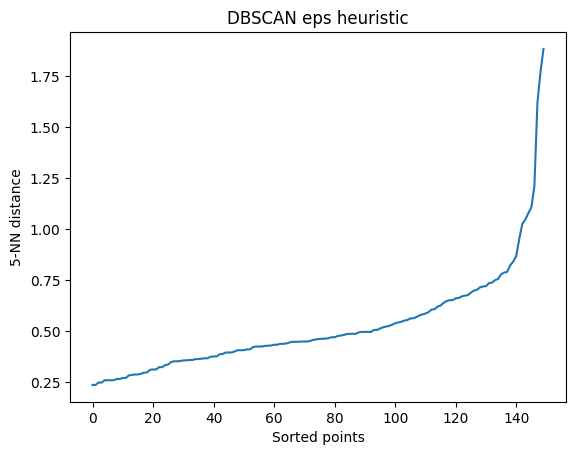

In [349]:
# Find optimal eps using 5-nearest neighbors
neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(X_iris_scaled)
distances, indices = neighbors_fit.kneighbors(X_iris_scaled)
distances = np.sort(distances[:, 4])  # 4 = min_samples - 1
plt.plot(distances)
plt.ylabel("5-NN distance")
plt.xlabel("Sorted points")
plt.title("DBSCAN eps heuristic")
plt.show()

In [409]:
results_dbscan, y_pred_dbscan = run_density_based(X_iris_scaled, y_iris, method='dbscan', eps=0.45, min_samples=5)
results_optics, y_pred_optics = run_density_based(X_iris_scaled, y_iris, method='optics', xi=0.12, min_samples=5)
pd.DataFrame([results_dbscan, results_optics]).set_index("Algorithm")


,Rand,Adj Rand,MI,Adj MI,Norm MI,Silhouette,Calinski,Davies,SSE,SSB,Accuracy
Algorithm,,,,,,,,,,,
DBSCAN,0.794810,0.517100,0.709498,0.583187,0.590347,0.180598,51.240777,3.544692,292.270514,307.729486,0.746667
OPTICS,0.776286,0.568116,0.636514,0.731585,0.733680,0.581750,251.349339,0.593313,222.361705,377.638295,0.666667


## Assignment

In [410]:
ds_name = 'iris'
all_results = {}

# Load and preprocess
X, y, feat_names, target_names = load_dataset(ds_name)
# print(f"Unique labels ({ds_name}):", np.unique(y))
# print("First 5 samples:\n", X[:5])

X_scaled, _ = preprocess_data(X)

# Store dataset-specific results
results_list = []

# --- Partition-based ---
results_kmeans, y_pred_kmeans, _ = run_kmeans(X_scaled, y, k=len(np.unique(y)))
results_list.append(results_kmeans)

results_kmedoids, y_pred_kmedoids, _ = run_kmedoids(X_scaled, y, k=len(np.unique(y)))
results_list.append(results_kmedoids)

results_bkm, y_pred_bkm, _ = run_bisecting_kmeans(X_scaled, y, k=len(np.unique(y)))
results_list.append(results_bkm)

# --- Hierarchical ---
results_hier, y_pred_hier = run_hierarchical(X_scaled, y, k=len(np.unique(y)), linkage_method='ward', plot_dendrogram=False)
results_list.append(results_hier)

results_divisive, y_pred_divisive = run_divisive_hierarchical(X_scaled, y, k=len(np.unique(y)))
results_list.append(results_divisive)

results_exact_div, y_pred_exact_div = exact_divisive(X_scaled, y, k=len(np.unique(y)))
results_list.append(results_exact_div)

# --- Density-based ---
results_dbscan, y_pred_dbscan = run_density_based(X_scaled, y, method='dbscan', eps=0.45, min_samples=5)
results_list.append(results_dbscan)

results_optics, y_pred_optics = run_density_based(X_scaled, y, method='optics', xi=0.12, min_samples=5)
results_list.append(results_optics)

# Merge into a single DataFrame
df_results = pd.DataFrame(results_list).set_index("Algorithm")
all_results[ds_name] = df_results

# Display the table
print(f"\n=== {ds_name.upper()} Dataset: Clustering Performance ===\n")
display(df_results)

Loaded 'iris' dataset: 150 samples, 4 features, 3 classes.
Preprocessing complete:
  - Mean of each feature after scaling (approx): [-0. -0. -0. -0.]
  - Std of each feature after scaling (approx): [1. 1. 1. 1.]

=== IRIS Dataset: Clustering Performance ===



,Rand,Adj Rand,MI,Adj MI,Norm MI,Silhouette,Calinski,Davies,SSE,SSB,Accuracy
Algorithm,,,,,,,,,,,
KMeans (k=3),0.832215,0.620135,0.724124,0.655223,0.659487,0.459948,241.904402,0.833595,139.820496,460.179504,0.833333
KMedoids (k=3),0.856823,0.676454,0.767794,0.696651,0.700410,0.450791,238.547924,0.831681,141.324446,458.675554,0.866667
Bisecting KMeans (k=3),0.832215,0.620135,0.724124,0.655223,0.659487,0.459948,241.904402,0.833595,139.820496,460.179504,0.833333
"Hierarchical (ward, k=3)",0.825235,0.615323,0.722757,0.671286,0.675470,0.446689,222.719164,0.803467,148.876256,451.123744,0.826667
Divisive Hierarchical (k=3),0.827830,0.610073,0.716734,0.648209,0.652558,0.459378,241.893262,0.834000,139.825435,460.174565,0.826667
Exact Divisive Hierarchical (k=3),0.827830,0.610073,0.716734,0.648209,0.652558,0.459378,241.893262,0.834000,139.825435,460.174565,0.826667
DBSCAN,0.794810,0.517100,0.709498,0.583187,0.590347,0.180598,51.240777,3.544692,292.270514,307.729486,0.746667
OPTICS,0.776286,0.568116,0.636514,0.731585,0.733680,0.581750,251.349339,0.593313,222.361705,377.638295,0.666667


In [319]:
ds_name = 'wine'

all_results = {}

X, y, feat_names, target_names = load_dataset(ds_name)
# print(f"Unique labels ({ds_name}):", np.unique(y))
# print("First 5 samples:\n", X[:5])

X_scaled, _ = preprocess_data(X)

# Store dataset-specific results
results_list = []

# --- Partition-based ---
results_kmeans, y_pred_kmeans, _ = run_kmeans(X_scaled, y, k=len(np.unique(y)))
results_list.append(results_kmeans)

results_kmedoids, y_pred_kmedoids, _ = run_kmedoids(X_scaled, y, k=len(np.unique(y)))
results_list.append(results_kmedoids)

results_bkm, y_pred_bkm, _ = run_bisecting_kmeans(X_scaled, y, k=len(np.unique(y)))
results_list.append(results_bkm)

# --- Hierarchical ---
results_hier, y_pred_hier = run_hierarchical(X_scaled, y, k=len(np.unique(y)), linkage_method='ward', plot_dendrogram=False)
results_list.append(results_hier)

results_divisive, y_pred_divisive = run_divisive_hierarchical(X_scaled, y, k=len(np.unique(y)))
results_list.append(results_divisive)

results_exact_div, y_pred_exact_div = exact_divisive(X_scaled, y, k=len(np.unique(y)))
results_list.append(results_exact_div)

# --- Density-based ---
results_dbscan, y_pred_dbscan = run_density_based(X_scaled, y, method='dbscan', eps=2.25, min_samples=5)
results_list.append(results_dbscan)

results_optics, y_pred_optics = run_density_based(X_scaled, y, method='optics', xi=0.05, min_samples=5)
results_list.append(results_optics)

# Merge into a single DataFrame
df_results = pd.DataFrame(results_list).set_index("Algorithm")
all_results[ds_name] = df_results

# Display the table
print(f"\n=== {ds_name.upper()} Dataset: Clustering Performance ===\n")
display(df_results)

Loaded 'wine' dataset: 178 samples, 13 features, 3 classes.
Preprocessing complete:
  - Mean of each feature after scaling (approx): [ 0.  0. -0. -0. -0. -0.  0. -0. -0. -0.  0.  0. -0.]
  - Std of each feature after scaling (approx): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]

=== WINE Dataset: Clustering Performance ===



,Rand,Adj Rand,MI,Adj MI,Norm MI,Silhouette,Calinski,Davies,SSE,SSB,Accuracy
Algorithm,,,,,,,,,,,
KMeans (k=3),0.954294,0.897495,0.954458,0.874579,0.875894,0.284859,70.940008,1.389188,1277.928489,1036.071511,0.966292
KMedoids (k=3),0.877484,0.726341,0.821479,0.753986,0.756574,0.265977,66.751966,1.415990,1312.625089,1001.374911,0.904494
Bisecting KMeans (k=3),0.812988,0.590631,0.751549,0.701892,0.705090,0.234076,59.742457,1.520319,1375.112890,938.887110,0.837079
"Hierarchical (ward, k=3)",0.906494,0.789933,0.858437,0.784208,0.786465,0.277444,67.647468,1.418592,1305.048695,1008.951305,0.926966
Divisive Hierarchical (k=3),0.868977,0.706152,0.808709,0.739411,0.742142,0.267797,66.394571,1.428594,1315.673446,998.326554,0.887640
Exact Divisive Hierarchical (k=3),0.868977,0.706152,0.808709,0.739411,0.742142,0.267797,66.394571,1.428594,1315.673446,998.326554,0.887640
DBSCAN,0.722656,0.396239,0.512780,0.477828,0.483461,0.165469,28.633243,3.627038,1743.471512,570.528488,0.713483
OPTICS,0.439154,0.035817,0.162126,0.167991,0.194946,-0.133640,5.057149,1.619371,2071.753404,242.246596,0.410112
